In [50]:
#!pip install nixtla

In [1]:
import pandas as pd
from nixtla import NixtlaClient
nixtla_client = NixtlaClient(api_key = 'nixak-fdeb395c1c38014d4292173c77382d77112264957706fd4bfd4ba3ea8d27da243ee0fa406f4a8105')
nixtla_client.validate_api_key()

INFO:nixtla.nixtla_client:Happy Forecasting! :)


True

In [2]:
## Load the data from file/files

In [3]:
#load data from cities

# 2. Read historic electricity demand data
#df = pd.read_csv('polandia_hourly.csv')
df = pd.read_csv('fromCale/daily_data_pl.csv')
df

,utc_timestamp,PL_load_actual_entsoe_transparency
0,2015-01-01,15098.416667
1,2015-01-02,17869.250000
2,2015-01-03,17684.916667
3,2015-01-04,16453.666667
4,2015-01-05,18856.416667
...,...,...
1821,2019-12-27,17550.958333
1822,2019-12-28,17807.750000
1823,2019-12-29,16809.500000
1824,2019-12-30,18698.416667


## Select training data based on Scenario

In [4]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-10-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
trainData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
trainData

,utc_timestamp,PL_load_actual_entsoe_transparency
1096,2018-01-01,15160.041667
1097,2018-01-02,19363.875000
1098,2018-01-03,20946.416667
1099,2018-01-04,21110.083333
1100,2018-01-05,21081.458333
...,...,...
1395,2018-10-27,18693.541667
1396,2018-10-28,17114.583333
1397,2018-10-29,20727.166667
1398,2018-10-30,20527.958333


In [5]:
len(trainData)

304

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


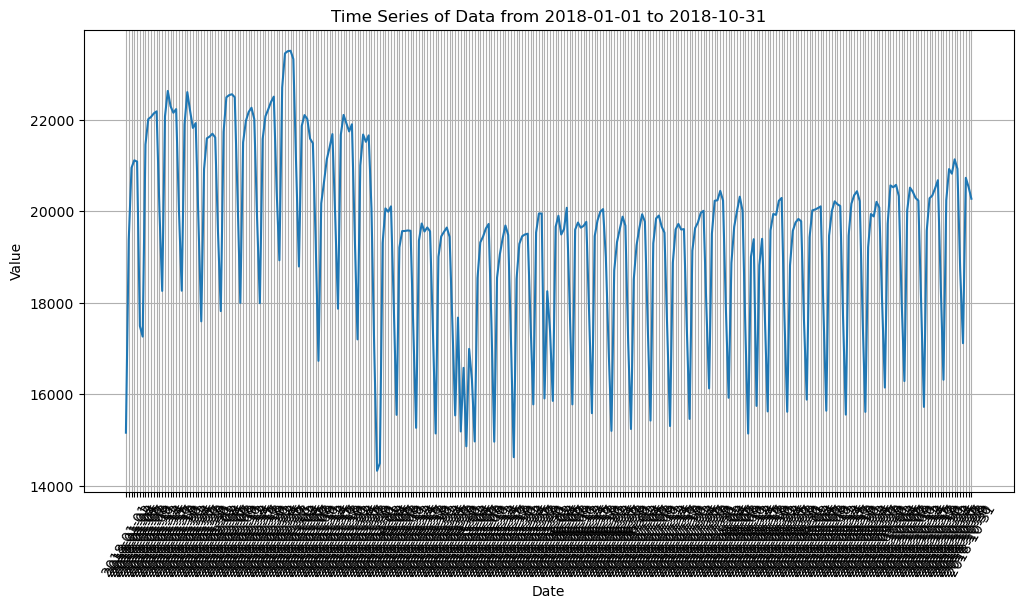

In [6]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Value')
plt.grid(True)
plt.show()

## Validation data selection based on scenario

In [10]:
# Select data for validation # 
fra = '2018-11-01'
til = '2018-12-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
validData = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
validData = validData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'actual'})
validData

,ds,actual
1400,2018-11-01,15459.333333
1401,2018-11-02,18092.916667
1402,2018-11-03,17951.875000
1403,2018-11-04,16554.500000
1404,2018-11-05,20137.500000
...,...,...
1456,2018-12-27,18639.583333
1457,2018-12-28,19116.583333
1458,2018-12-29,18229.500000
1459,2018-12-30,16873.250000


In [11]:
len(validData)

61

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


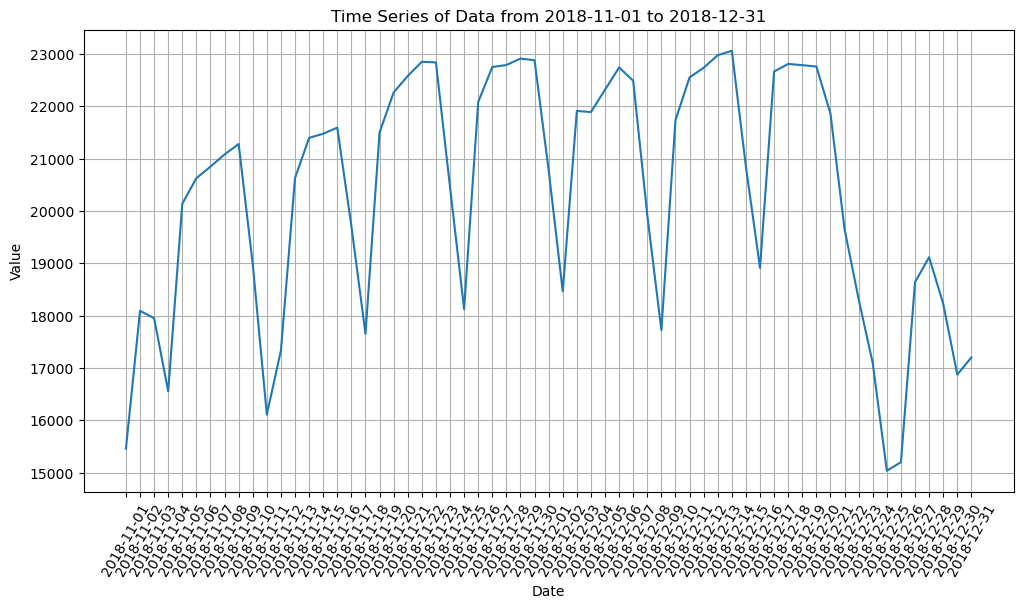

In [12]:
# Basic time series plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(validData['ds'], validData['actual'])
plt.title(f'Time Series of Data from {fra} to {til}')
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
   
plt.ylabel('Value')
plt.grid(True)
plt.show()


## Forcasting wsith timeGPT

In [13]:
# 3. Forecast the next 24 hours
# First, ensure your DataFrame has the required column names
# Nixtla typically expects 'ds' for the timestamp column and 'y' for the target variable

# Assuming trainData has a datetime column with a different name (e.g., 'date' or 'timestamp')
# Rename it to match Nixtla's expected format
trainData = trainData.rename(columns={'utc_timestamp': 'ds', 'PL_load_actual_entsoe_transparency': 'y'})

# Now try forecasting again
fcst_df = nixtla_client.forecast(trainData, 
                                 h=len(validData), 
                                 freq='D',
                                 model='timegpt-1-long-horizon')

INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...
INFO:nixtla.nixtla_client:Restricting input...
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


In [14]:
fcst_df

,ds,TimeGPT
0,2018-11-01,20639.502
1,2018-11-02,20316.195
2,2018-11-03,17815.652
3,2018-11-04,16350.486
4,2018-11-05,19713.602
...,...,...
56,2018-12-27,19939.290
57,2018-12-28,19543.180
58,2018-12-29,17369.080
59,2018-12-30,16061.763


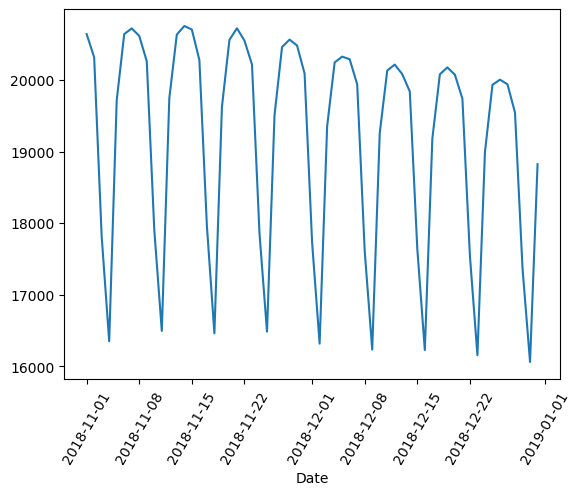

In [15]:
# Membuat plot
plt.plot(fcst_df['ds'], fcst_df['TimeGPT'])
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])
#plt.plot(trainData['utc_timestamp'], trainData['PL_load_actual_entsoe_transparency'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Date')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees


# Menampilkan plot
plt.show()

## Merge forecast n actual

In [16]:
# Convert the 'ds' column in both DataFrames to the same data type (datetime)
fcst_df['ds'] = pd.to_datetime(fcst_df['ds'])
validData['ds'] = pd.to_datetime(validData['ds'])

# Now merge the DataFrames
result = pd.merge(fcst_df, validData, on='ds', how='inner')

In [17]:
result

,ds,TimeGPT,actual
0,2018-11-01,20639.502,15459.333333
1,2018-11-02,20316.195,18092.916667
2,2018-11-03,17815.652,17951.875000
3,2018-11-04,16350.486,16554.500000
4,2018-11-05,19713.602,20137.500000
...,...,...,...
56,2018-12-27,19939.290,18639.583333
57,2018-12-28,19543.180,19116.583333
58,2018-12-29,17369.080,18229.500000
59,2018-12-30,16061.763,16873.250000


## Metrics calculation (rRMSE and rMAE)

In [18]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['actual'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['actual'] - result['TimeGPT']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['actual'] - result['TimeGPT'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)



rRMSE: 0.1118 rMAE: 0.0970 


## Comparison of GPT vs Actual

In [19]:
city = 'Daily Poland TimeGPT'

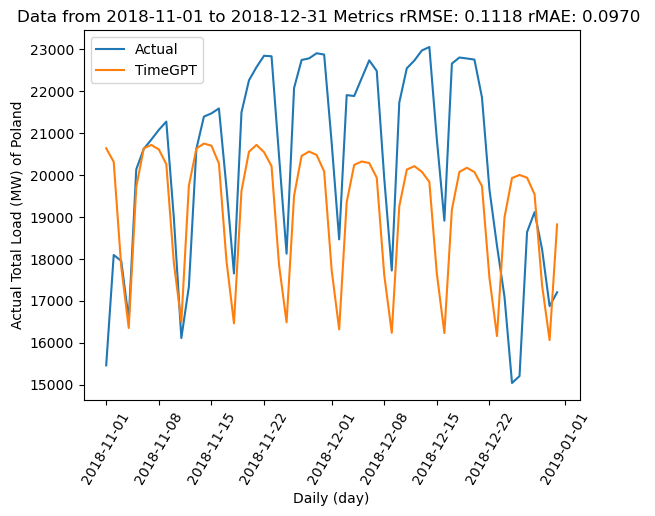

In [20]:
# plot Result dan save

plt.plot(result['ds'], result['actual'], label='Actual')
plt.plot(result['ds'], result['TimeGPT'],label='TimeGPT')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Daily (day)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Poland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
